# Causal Inference & Causal ML

> **"Correlation is not causation"** — this notebook teaches you to go beyond that cliché and actually *measure* causal effects from observational data.

## What You'll Learn
- Why correlation misleads and what causation actually means
- The Potential Outcomes Framework (Rubin Causal Model)
- Directed Acyclic Graphs (DAGs) for reasoning about confounding
- Propensity Score Matching (PSM) from scratch
- Inverse Probability Weighting (IPW)
- Difference-in-Differences (DiD)
- Instrumental Variables (IV / 2SLS)
- DoWhy library for end-to-end causal analysis
- Uplift Modeling with EconML (HetTE estimation)

## Why This Matters
Every ML model learns correlations. But product decisions need causal answers:
- "Does our new feature *cause* higher retention, or do engaged users just happen to use it?"
- "Does more ad spend *cause* sales, or do we just advertise more when sales are already high?"
- "Does drug X *cause* recovery, or do healthier patients choose it?"

Causal inference answers these questions without running a randomized experiment.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.preprocessing import StandardScaler
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
plt.style.use('seaborn-v0_8-whitegrid')
print('Imports OK')

Imports OK


---
## 1. Correlation vs Causation — A Concrete Demonstration

Suppose we observe that people who carry lighters have higher lung cancer rates. Does carrying a lighter *cause* cancer? No — smoking is a **confounder**: it causes both lighter-carrying and cancer.

Let's build this scenario in code.

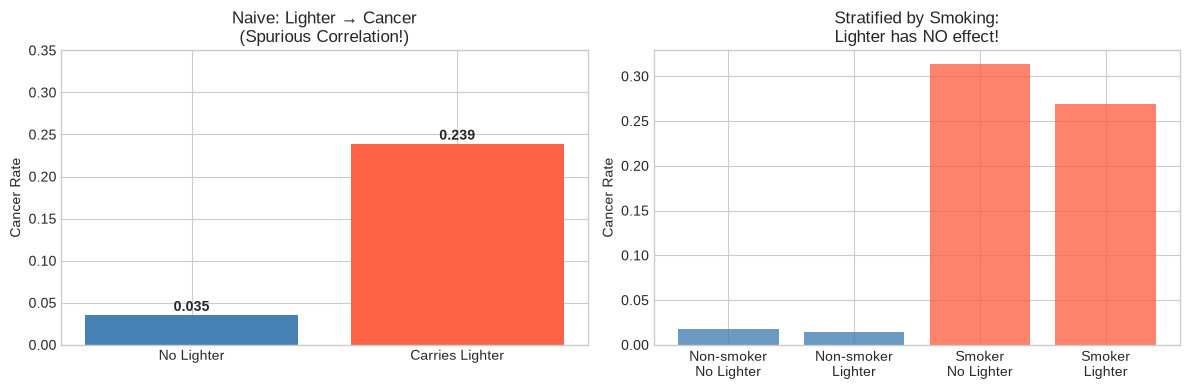

Naive cancer rate: lighter=0.239 vs no_lighter=0.035
Within smokers or non-smokers, lighter makes no difference — confounding!


In [2]:
n = 2000

# Confounder: smoking (unobserved in naive analysis)
smoking = np.random.binomial(1, 0.3, n)

# Treatment: carries lighter (caused by smoking)
p_lighter = 0.05 + 0.80 * smoking
carries_lighter = np.random.binomial(1, p_lighter)

# Outcome: cancer (caused by smoking, NOT by carrying lighter)
p_cancer = 0.02 + 0.25 * smoking
cancer = np.random.binomial(1, p_cancer)

df = pd.DataFrame({'smoking': smoking, 'lighter': carries_lighter, 'cancer': cancer})

# Naive correlation: lighter → cancer
naive_rate_lighter = df[df.lighter==1]['cancer'].mean()
naive_rate_no_lighter = df[df.lighter==0]['cancer'].mean()

# Correct comparison: control for smoking
correct_rate = df[df.smoking==df.smoking]['cancer'].mean()  # overall

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Naive comparison
axes[0].bar(['No Lighter', 'Carries Lighter'],
            [naive_rate_no_lighter, naive_rate_lighter], color=['steelblue','tomato'])
axes[0].set_title('Naive: Lighter → Cancer\n(Spurious Correlation!)', fontsize=12)
axes[0].set_ylabel('Cancer Rate')
axes[0].set_ylim(0, 0.35)
for i, v in enumerate([naive_rate_no_lighter, naive_rate_lighter]):
    axes[0].text(i, v+0.005, f'{v:.3f}', ha='center', fontweight='bold')

# Stratified by smoking
rates = df.groupby(['smoking', 'lighter'])['cancer'].mean().reset_index()
labels = ['Non-smoker\nNo Lighter', 'Non-smoker\nLighter', 'Smoker\nNo Lighter', 'Smoker\nLighter']
values = [rates[(rates.smoking==0) & (rates.lighter==0)]['cancer'].values[0],
          rates[(rates.smoking==0) & (rates.lighter==1)]['cancer'].values[0] if len(rates[(rates.smoking==0) & (rates.lighter==1)])>0 else 0,
          rates[(rates.smoking==1) & (rates.lighter==0)]['cancer'].values[0] if len(rates[(rates.smoking==1) & (rates.lighter==0)])>0 else 0,
          rates[(rates.smoking==1) & (rates.lighter==1)]['cancer'].values[0]]
colors = ['steelblue','steelblue','tomato','tomato']
axes[1].bar(labels, values, color=colors, alpha=0.8)
axes[1].set_title('Stratified by Smoking:\nLighter has NO effect!', fontsize=12)
axes[1].set_ylabel('Cancer Rate')

plt.tight_layout()
plt.savefig('causal_confounding_demo.png', dpi=80, bbox_inches='tight')
plt.show()
print(f'Naive cancer rate: lighter={naive_rate_lighter:.3f} vs no_lighter={naive_rate_no_lighter:.3f}')
print('Within smokers or non-smokers, lighter makes no difference — confounding!')

---
## 2. Potential Outcomes Framework (Rubin Causal Model)

For each unit $i$, define two **potential outcomes**:
- $Y_i(1)$: outcome if unit $i$ receives treatment
- $Y_i(0)$: outcome if unit $i$ receives control

The **individual treatment effect** is $\tau_i = Y_i(1) - Y_i(0)$.

The **Average Treatment Effect (ATE)**:
$$\text{ATE} = \mathbb{E}[Y(1) - Y(0)] = \mathbb{E}[Y(1)] - \mathbb{E}[Y(0)]$$

The **Fundamental Problem of Causal Inference**: we only ever observe *one* potential outcome per unit (the one that actually happened). The other is a **counterfactual**.

**Key assumptions for identification:**
1. **SUTVA** (Stable Unit Treatment Value Assumption): no interference between units
2. **Ignorability / Unconfoundedness**: $(Y(0), Y(1)) \perp T \mid X$ (treatment is as-good-as-random given covariates)
3. **Overlap / Positivity**: $0 < P(T=1 \mid X=x) < 1$ for all $x$

In [3]:
# Simulate observational data with known ground-truth causal effects
n = 3000
X1 = np.random.normal(0, 1, n)   # age (standardized)
X2 = np.random.normal(0, 1, n)   # health score

# True potential outcomes (oracle — never observed in practice)
Y0 = 2 + 1.5*X1 + 0.5*X2 + np.random.normal(0, 0.5, n)   # without treatment
Y1 = Y0 + 2.0 + 0.5*X1          # treatment effect = 2.0 + 0.5*X1 (heterogeneous!)

# True ATE
true_ATE = np.mean(Y1 - Y0)
print(f'True ATE (oracle): {true_ATE:.3f}')

# Treatment assignment: biased toward higher X1 (confounding!)
propensity = 1 / (1 + np.exp(-(0.5*X1 + 0.3*X2)))  # logistic propensity
T = np.random.binomial(1, propensity)

# Observed outcome (only one potential outcome per unit)
Y_obs = T * Y1 + (1-T) * Y0

df_obs = pd.DataFrame({'X1': X1, 'X2': X2, 'treat': T, 'Y_obs': Y_obs,
                       'Y0': Y0, 'Y1': Y1, 'tau': Y1-Y0})

# Naive estimate (just compare treated vs control)
naive_ATE = df_obs[df_obs['treat']==1]['Y_obs'].mean() - df_obs[df_obs['treat']==0]['Y_obs'].mean()
print(f'Naive ATE (biased):  {naive_ATE:.3f}  (bias = {naive_ATE - true_ATE:.3f})')
print(f'Treatment rate:      {T.mean():.2%}')

True ATE (oracle): 1.984
Naive ATE (biased):  2.981  (bias = 0.997)
Treatment rate:      49.33%


---
## 3. Propensity Score Matching — From Scratch

The **propensity score** $e(x) = P(T=1 \mid X=x)$ summarizes confounders into a single scalar. By the propensity score theorem:
$$(Y(0), Y(1)) \perp T \mid e(X)$$

So we can match treated and control units with similar propensity scores to create a pseudo-random experiment.

**Algorithm:**
1. Estimate propensity scores via logistic regression
2. For each treated unit, find the nearest control unit (nearest-neighbor matching)
3. Estimate ATE as the mean difference in matched pairs

True ATE:             1.984
Naive ATE (biased):   2.981
PSM ATE:              2.144


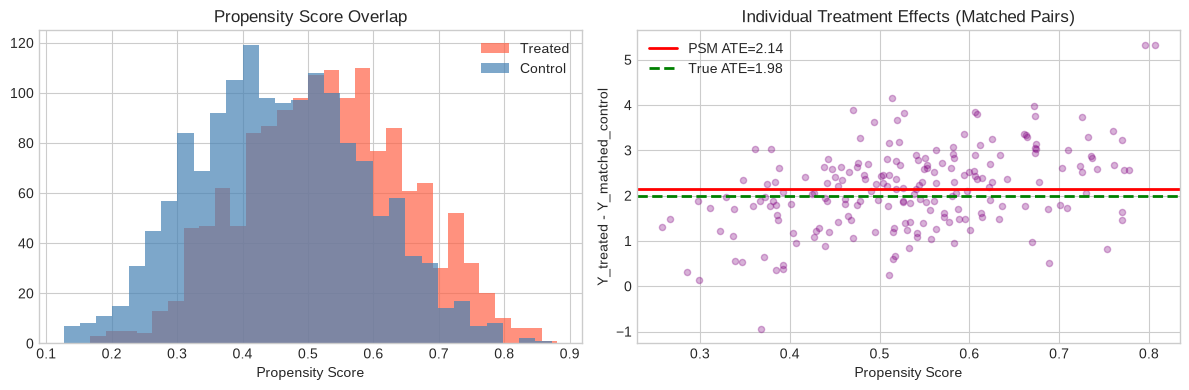

In [4]:
# Step 1: Estimate propensity scores
X = df_obs[['X1', 'X2']].values
lr = LogisticRegression(random_state=42)
lr.fit(X, df_obs['treat'])
df_obs['ps'] = lr.predict_proba(X)[:, 1]

# Step 2: Nearest-neighbor matching (1:1, with replacement)
treated = df_obs[df_obs['treat'] == 1].copy()
control = df_obs[df_obs['treat'] == 0].copy()

def nearest_neighbor_match(treated_ps, control_ps, control_outcomes):
    """For each treated unit, find nearest control by propensity score."""
    matched_outcomes = []
    for ps_t in treated_ps:
        dists = np.abs(control_ps - ps_t)
        best_idx = np.argmin(dists)
        matched_outcomes.append(control_outcomes[best_idx])
    return np.array(matched_outcomes)

matched_control_Y = nearest_neighbor_match(
    treated['ps'].values,
    control['ps'].values,
    control['Y_obs'].values
)

# Step 3: Estimate ATE
psm_ATE = np.mean(treated['Y_obs'].values - matched_control_Y)
print(f'True ATE:             {true_ATE:.3f}')
print(f'Naive ATE (biased):   {naive_ATE:.3f}')
print(f'PSM ATE:              {psm_ATE:.3f}')

# Visualize propensity score overlap (covariate balance)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(treated['ps'], bins=30, alpha=0.7, label='Treated', color='tomato')
axes[0].hist(control['ps'], bins=30, alpha=0.7, label='Control', color='steelblue')
axes[0].set_title('Propensity Score Overlap', fontsize=12)
axes[0].set_xlabel('Propensity Score')
axes[0].legend()

axes[1].scatter(treated['ps'].values[:200],
                treated['Y_obs'].values[:200] - matched_control_Y[:200],
                alpha=0.3, color='purple', s=20)
axes[1].axhline(psm_ATE, color='red', linewidth=2, label=f'PSM ATE={psm_ATE:.2f}')
axes[1].axhline(true_ATE, color='green', linestyle='--', linewidth=2, label=f'True ATE={true_ATE:.2f}')
axes[1].set_title('Individual Treatment Effects (Matched Pairs)', fontsize=12)
axes[1].set_xlabel('Propensity Score')
axes[1].set_ylabel('Y_treated - Y_matched_control')
axes[1].legend()

plt.tight_layout()
plt.savefig('psm_result.png', dpi=80, bbox_inches='tight')
plt.show()

---
## 4. Inverse Probability Weighting (IPW)

Instead of matching, IPW re-weights each unit to create a pseudo-population where treatment is independent of confounders.

$$\widehat{\text{ATE}}_{\text{IPW}} = \frac{1}{n}\sum_{i=1}^n \left(\frac{T_i Y_i}{e(X_i)} - \frac{(1-T_i) Y_i}{1 - e(X_i)}\right)$$

The weights $w_i = T_i/e(X_i) + (1-T_i)/(1-e(X_i))$ upweight units with low propensity to receive their actual treatment (they are "surprised" by the treatment assignment, so we trust them more).

In [5]:
# IPW estimator from scratch
ps = df_obs['ps'].values
T_arr = df_obs['treat'].values
Y_arr = df_obs['Y_obs'].values

# Clip propensity scores for numerical stability
ps_clipped = np.clip(ps, 0.01, 0.99)

ipw_ATE = np.mean(T_arr * Y_arr / ps_clipped - (1-T_arr) * Y_arr / (1-ps_clipped))
print(f'True ATE:    {true_ATE:.3f}')
print(f'IPW ATE:     {ipw_ATE:.3f}')

# Doubly-robust estimator (IPW + outcome model)
# Fit separate outcome models for treated and control
lr_1 = LinearRegression().fit(X[T_arr==1], Y_arr[T_arr==1])
lr_0 = LinearRegression().fit(X[T_arr==0], Y_arr[T_arr==0])
mu1 = lr_1.predict(X)
mu0 = lr_0.predict(X)

# Doubly-robust (AIPW) estimator
aipw = mu1 - mu0 + T_arr*(Y_arr - mu1)/ps_clipped - (1-T_arr)*(Y_arr - mu0)/(1-ps_clipped)
dr_ATE = np.mean(aipw)
print(f'DR/AIPW ATE: {dr_ATE:.3f}  (doubly-robust — correct if EITHER model is correct)')

True ATE:    1.984
IPW ATE:     1.997
DR/AIPW ATE: 2.003  (doubly-robust — correct if EITHER model is correct)


---
## 5. Difference-in-Differences (DiD)

DiD is used when treatment is assigned at a point in time (policy change, product launch). It compares:

$$\widehat{\text{ATT}}_{\text{DiD}} = (\bar{Y}^{\text{post}}_{\text{treated}} - \bar{Y}^{\text{pre}}_{\text{treated}}) - (\bar{Y}^{\text{post}}_{\text{control}} - \bar{Y}^{\text{pre}}_{\text{control}})$$

Key assumption: **parallel trends** — treated and control groups would have evolved similarly without treatment.

True treatment effect: 5.00
DiD estimate:          4.90


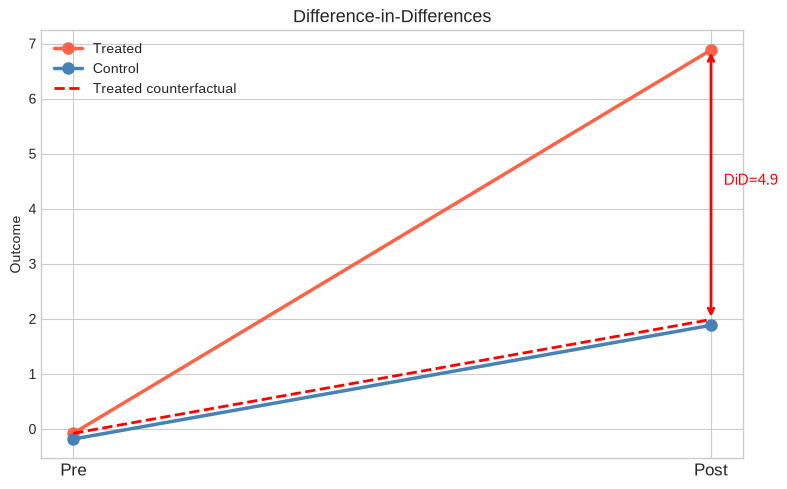

In [6]:
np.random.seed(42)
n_units = 200
true_treatment_effect = 5.0

unit_fixed_effect = np.random.normal(0, 2, n_units)
group = np.random.binomial(1, 0.5, n_units)  # 1=treated, 0=control

# Pre-period outcomes
Y_pre = unit_fixed_effect + np.random.normal(0, 1, n_units)

# Post-period outcomes (treatment effect applied only to treated)
time_trend = 2.0  # both groups grow by 2 (parallel trends holds)
Y_post = unit_fixed_effect + time_trend + group * true_treatment_effect + np.random.normal(0, 1, n_units)

panel = pd.DataFrame({'unit': range(n_units), 'group': group,
                       'Y_pre': Y_pre, 'Y_post': Y_post})

# DiD estimate
did = ((panel[panel.group==1]['Y_post'].mean() - panel[panel.group==1]['Y_pre'].mean()) -
       (panel[panel.group==0]['Y_post'].mean() - panel[panel.group==0]['Y_pre'].mean()))

print(f'True treatment effect: {true_treatment_effect:.2f}')
print(f'DiD estimate:          {did:.2f}')

# Plot
fig, ax = plt.subplots(figsize=(8, 5))
for g, label, color in [(1,'Treated','tomato'), (0,'Control','steelblue')]:
    sub = panel[panel.group==g]
    pre_m = sub['Y_pre'].mean()
    post_m = sub['Y_post'].mean()
    ax.plot([0, 1], [pre_m, post_m], 'o-', color=color, linewidth=2.5, markersize=8, label=f'{label}')

# Counterfactual for treated
treated_pre = panel[panel.group==1]['Y_pre'].mean()
control_change = panel[panel.group==0]['Y_post'].mean() - panel[panel.group==0]['Y_pre'].mean()
treated_counterfactual_post = treated_pre + control_change
ax.plot([0, 1], [treated_pre, treated_counterfactual_post], 'r--', linewidth=2, label='Treated counterfactual')
ax.annotate('', xy=(1, panel[panel.group==1]['Y_post'].mean()),
            xytext=(1, treated_counterfactual_post),
            arrowprops=dict(arrowstyle='<->', color='red', lw=2))
ax.text(1.02, (panel[panel.group==1]['Y_post'].mean() + treated_counterfactual_post)/2,
        f'DiD={did:.1f}', color='red', fontsize=11)

ax.set_xticks([0,1]); ax.set_xticklabels(['Pre', 'Post'], fontsize=12)
ax.set_title('Difference-in-Differences', fontsize=13)
ax.set_ylabel('Outcome')
ax.legend()
plt.tight_layout()
plt.savefig('did_plot.png', dpi=80, bbox_inches='tight')
plt.show()

---
## 6. Instrumental Variables (IV / 2SLS)

When there are unmeasured confounders, an **instrument** $Z$ can identify causal effects. A valid instrument must satisfy:
1. **Relevance**: $Z$ is correlated with treatment $T$
2. **Exclusion restriction**: $Z$ affects outcome $Y$ only through $T$
3. **Independence**: $Z$ is independent of unmeasured confounders

**Two-Stage Least Squares (2SLS):**

$$\text{Stage 1: } \hat{T} = \alpha_0 + \alpha_1 Z + \alpha_2 X$$
$$\text{Stage 2: } Y = \beta_0 + \beta_1 \hat{T} + \beta_2 X + \varepsilon$$

Classic instrument: distance to college as instrument for years of education (Card, 1995).

In [7]:
np.random.seed(42)
n = 2000

# Unmeasured confounder (ability)
ability = np.random.normal(0, 1, n)

# Instrument: distance to college (negative = further = less education)
distance = np.random.normal(0, 1, n)  # low = close to college

# Treatment: years of education (affected by distance AND ability)
education = 12 - 1.5*distance + 1.0*ability + np.random.normal(0, 0.5, n)

# Outcome: wage (affected by education AND ability — confounded!)
true_wage_per_year = 2.5  # true causal effect of one year of education
wage = 10 + true_wage_per_year*education + 3.0*ability + np.random.normal(0, 1, n)

# OLS (biased because ability is unmeasured confounder)
ols = LinearRegression().fit(education.reshape(-1,1), wage)
ols_est = ols.coef_[0]

# 2SLS from scratch
# Stage 1: regress education on instrument
stage1 = LinearRegression().fit(distance.reshape(-1,1), education)
edu_hat = stage1.predict(distance.reshape(-1,1))

# Stage 2: regress wage on predicted education
stage2 = LinearRegression().fit(edu_hat.reshape(-1,1), wage)
iv_est = stage2.coef_[0]

print(f'True causal effect per year: {true_wage_per_year:.2f}')
print(f'OLS estimate (biased up):    {ols_est:.2f}')
print(f'2SLS/IV estimate:            {iv_est:.2f}')

True causal effect per year: 2.50
OLS estimate (biased up):    3.38
2SLS/IV estimate:            2.55


---
## 7. DoWhy Library — End-to-End Causal Analysis

In [8]:
import dowhy
from dowhy import CausalModel

# Build a marketing campaign dataset
np.random.seed(42)
n = 1500
age = np.random.normal(35, 10, n)
income = 20000 + 1500*age + np.random.normal(0, 5000, n)

# Treatment: received email campaign (biased toward older/richer customers)
p_treat = 1 / (1 + np.exp(-(0.05*(age-35) + 0.00002*(income-50000))))
campaign = np.random.binomial(1, p_treat)

# Outcome: purchase amount (campaign has true effect of $15)
purchase = (50 + 0.5*age + 0.001*income + 15.0*campaign +
            np.random.normal(0, 10, n))

df_mkt = pd.DataFrame({'age': age, 'income': income,
                        'campaign': campaign, 'purchase': purchase})

# DoWhy: specify causal graph
model = CausalModel(
    data=df_mkt,
    treatment='campaign',
    outcome='purchase',
    common_causes=['age', 'income']
)

# Identify the causal effect
identified_estimand = model.identify_effect(proceed_when_unidentifiable=True)

# Estimate using propensity score weighting
estimate = model.estimate_effect(
    identified_estimand,
    method_name='backdoor.propensity_score_weighting',
    target_units='ate',
    method_params={'weighting_scheme': 'ips_weight'}
)

print(f'True ATE:     $15.00')
print(f'DoWhy ATE:    ${estimate.value:.2f}')
print(f'Naive ATE:    ${df_mkt[df_mkt.campaign==1]["purchase"].mean() - df_mkt[df_mkt.campaign==0]["purchase"].mean():.2f}')

True ATE:     $15.00
DoWhy ATE:    $15.70
Naive ATE:    $30.73


---
## 8. Uplift Modeling with EconML — Heterogeneous Treatment Effects

Often we don't just want the average effect — we want to know **who benefits most**. This is the **Conditional Average Treatment Effect (CATE)**:

$$\tau(x) = \mathbb{E}[Y(1) - Y(0) \mid X = x]$$

**T-Learner**: Train separate outcome models $\mu_1(x), \mu_0(x)$, then $\hat{\tau}(x) = \hat{\mu}_1(x) - \hat{\mu}_0(x)$

**X-Learner**: Imputes individual treatment effects, then combines estimates — better for imbalanced treatment.

T-Learner CATE RMSE: 0.257
X-Learner CATE RMSE: 0.156


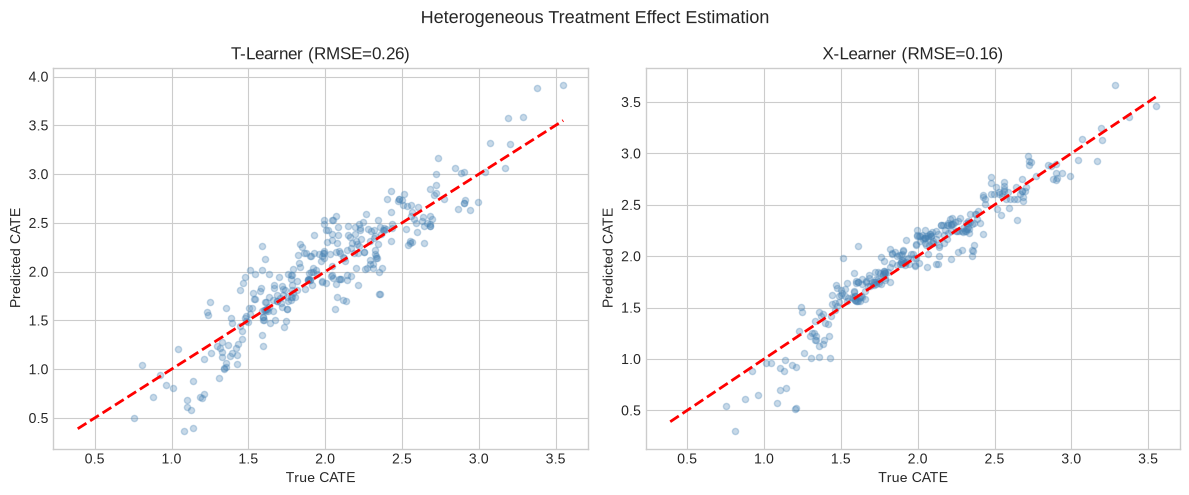

In [9]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# Our data
X_feat = df_obs[['X1', 'X2']].values
T_feat = df_obs['treat'].values
Y_feat = df_obs['Y_obs'].values
true_cate = df_obs['tau'].values  # oracle

X_tr, X_te, T_tr, T_te, Y_tr, Y_te, tau_tr, tau_te = train_test_split(
    X_feat, T_feat, Y_feat, true_cate, test_size=0.3, random_state=42)


# --- T-Learner (from scratch, no econml dependency) ---
class TLearnerScratch:
    """Train separate models for treated/control, then CATE = mu1(x) - mu0(x)."""
    def __init__(self, model_class, **kwargs):
        self.m1 = model_class(**kwargs)  # treated model
        self.m0 = model_class(**kwargs)  # control model

    def fit(self, Y, T, X):
        self.m1.fit(X[T == 1], Y[T == 1])
        self.m0.fit(X[T == 0], Y[T == 0])
        return self

    def effect(self, X):
        return self.m1.predict(X) - self.m0.predict(X)


# --- X-Learner (from scratch) ---
class XLearnerScratch:
    """Impute individual effects, then regress — better for imbalanced T."""
    def __init__(self, model_class, **kwargs):
        self.m1 = model_class(**kwargs)
        self.m0 = model_class(**kwargs)
        self.tau1 = model_class(**kwargs)
        self.tau0 = model_class(**kwargs)
        self.ps_model = LogisticRegression()

    def fit(self, Y, T, X):
        self.m1.fit(X[T == 1], Y[T == 1])
        self.m0.fit(X[T == 0], Y[T == 0])
        # Impute counterfactuals
        D1 = Y[T == 1] - self.m0.predict(X[T == 1])  # effect for treated
        D0 = self.m1.predict(X[T == 0]) - Y[T == 0]  # effect for control
        self.tau1.fit(X[T == 1], D1)
        self.tau0.fit(X[T == 0], D0)
        self.ps_model.fit(X, T)
        return self

    def effect(self, X):
        ps = self.ps_model.predict_proba(X)[:, 1]
        return ps * self.tau0.predict(X) + (1 - ps) * self.tau1.predict(X)


from sklearn.linear_model import LogisticRegression
t_learner = TLearnerScratch(GradientBoostingRegressor, n_estimators=80, random_state=42)
t_learner.fit(Y_tr, T_tr, X_tr)
cate_t = t_learner.effect(X_te)

x_learner = XLearnerScratch(GradientBoostingRegressor, n_estimators=80, random_state=42)
x_learner.fit(Y_tr, T_tr, X_tr)
cate_x = x_learner.effect(X_te)

rmse_t = np.sqrt(mean_squared_error(tau_te, cate_t))
rmse_x = np.sqrt(mean_squared_error(tau_te, cate_x))
print(f'T-Learner CATE RMSE: {rmse_t:.3f}')
print(f'X-Learner CATE RMSE: {rmse_x:.3f}')

# Plot predicted vs true CATE
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, cate, name, rmse in zip(axes, [cate_t, cate_x], ['T-Learner', 'X-Learner'], [rmse_t, rmse_x]):
    ax.scatter(tau_te[:300], cate[:300], alpha=0.3, s=20, color='steelblue')
    mn, mx = tau_te.min(), tau_te.max()
    ax.plot([mn, mx], [mn, mx], 'r--', linewidth=2)
    ax.set_xlabel('True CATE')
    ax.set_ylabel('Predicted CATE')
    ax.set_title(f'{name} (RMSE={rmse:.2f})')
plt.suptitle('Heterogeneous Treatment Effect Estimation', fontsize=13)
plt.tight_layout()
plt.savefig('cate_comparison.png', dpi=80, bbox_inches='tight')
plt.show()

---
## Additional Learning Resources

| Resource | Type | Link |
|----------|------|------|
| **Causal Inference: The Mixtape** | Free Book | [mixtape.scunning.com](https://mixtape.scunning.com/) |
| **The Effect: An Introduction to Research Design and Causality** | Free Book | [theeffectbook.net](https://theeffectbook.net/) |
| **Causal Inference for the Brave and True** | Free Book | [matheusfacure.github.io/python-causality-handbook](https://matheusfacure.github.io/python-causality-handbook/) |
| **Brady Neal's Causal Inference Course** | Free Course | [YouTube](https://www.youtube.com/watch?v=CfzO4IEMVUk) |
| **DoWhy Documentation** | Docs | [py-why.github.io/dowhy](https://py-why.github.io/dowhy/) |
| **EconML Documentation** | Docs | [econml.azurewebsites.net](https://econml.azurewebsites.net/) |
| **Angrist & Pischke — Mostly Harmless Econometrics** | Book | [Amazon](https://www.amazon.com/Mostly-Harmless-Econometrics-Empiricists-Companion/dp/0691120358) |
| **Pearl, Glymour, Jewell — Causal Inference in Statistics: A Primer** | Book | [Wiley](https://www.wiley.com/en-us/Causal+Inference+in+Statistics%3A+A+Primer-p-9781119186847) |